In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('../Datasets/Reviews.csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (568454, 10)


In [3]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 43.4 MB


In [5]:
print("Total unique users:", df['UserId'].nunique())
print("Total unique products:", df['ProductId'].nunique())
print("Total ratings:", len(df))
print("Average score:", round(df['Score'].mean(), 2))

Total unique users: 256059
Total unique products: 74258
Total ratings: 568454
Average score: 4.18


C:\Users\thaku\AppData\Local\Temp\ipykernel_13392\506531745.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Score', data=df, palette='viridis')


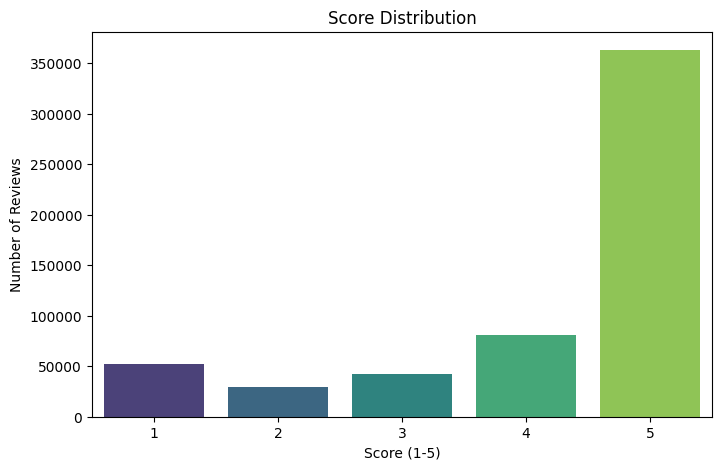

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(x='Score', data=df, palette='viridis')
plt.title('Score Distribution')
plt.xlabel('Score (1-5)')
plt.ylabel('Number of Reviews')
plt.show()

C:\Users\thaku\AppData\Local\Temp\ipykernel_13392\3401075626.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


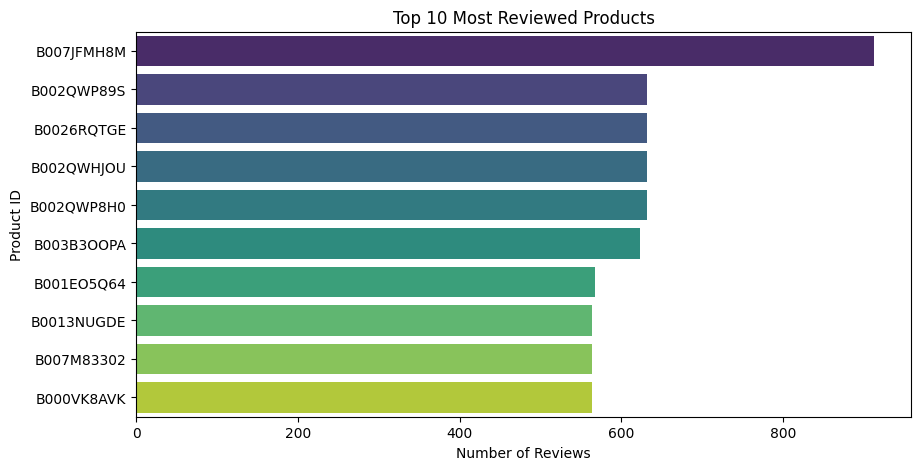

In [7]:
top_products = df['ProductId'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Most Reviewed Products')
plt.xlabel('Number of Reviews')
plt.ylabel('Product ID')
plt.show()

C:\Users\thaku\AppData\Local\Temp\ipykernel_13392\3483785908.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_users.values, y=top_users.index, palette='viridis')


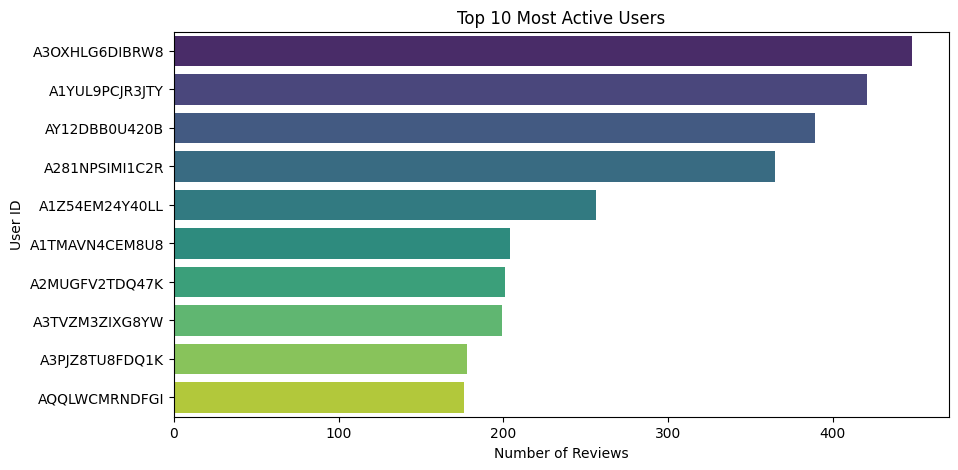

In [8]:
top_users = df['UserId'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_users.values, y=top_users.index, palette='viridis')
plt.title('Top 10 Most Active Users')
plt.xlabel('Number of Reviews')
plt.ylabel('User ID')
plt.show()

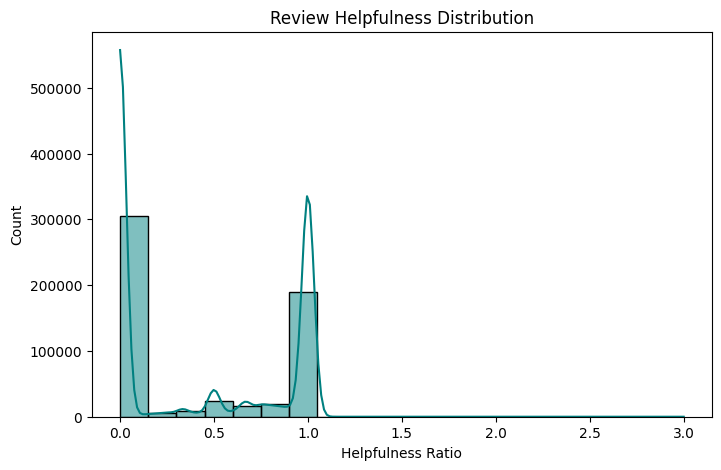

In [9]:
# How helpful were the reviews?
df['HelpfulnessRatio'] = df['HelpfulnessNumerator'] / df['HelpfulnessDenominator'].replace(0, 1)

plt.figure(figsize=(8,5))
sns.histplot(df['HelpfulnessRatio'], bins=20, kde=True, color='teal')
plt.title('Review Helpfulness Distribution')
plt.xlabel('Helpfulness Ratio')
plt.ylabel('Count')
plt.show()